In [1]:
# Resolve project paths when launched from the root or a project subfolder.
from pathlib import Path

PROJECT_ROOT = next(
    (p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
     if (p / "trial_manifest.json").is_file() and (p / "analysis").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Launch this notebook from the new G&P project folder or analysis folder.")
DATA_ROOT = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
from pathlib import Path

import pandas as pd
import numpy as np

DATA_ROOT = PROJECT_ROOT / "data"

PEOPLE = [
    "Buddhini",
    "Harshika",
    "Muthuni",
    "Nadeera",
    "Thenuri"
]

ORIGINAL_ANGLE_COLS = [
    "left_ankle_to_foot_original_angle",
    "left_elbow_to_wrist_original_angle",
    "left_hip_to_knee_original_angle",
    "left_knee_to_ankle_original_angle",
    "left_shoulder_to_elbow_original_angle",
    "left_wrist_to_hand_original_angle",
    "mid_to_upper_spine_original_angle",
    "neck_to_left_shoulder_original_angle",
    "neck_to_right_shoulder_original_angle",
    "pelvis_to_left_hip_original_angle",
    "pelvis_to_lower_spine_original_angle",
    "pelvis_to_right_hip_original_angle",
    "right_ankle_to_foot_original_angle",
    "right_elbow_to_wrist_original_angle",
    "right_hip_to_knee_original_angle",
    "right_knee_to_ankle_original_angle",
    "right_shoulder_to_elbow_original_angle",
    "right_wrist_to_hand_original_angle"
]

print("People:", PEOPLE)
print("Signals:", len(ORIGINAL_ANGLE_COLS))

C:\Users\MSI\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


People: ['Buddhini', 'Harshika', 'Muthuni', 'Nadeera', 'Thenuri']
Signals: 18


In [3]:
import matplotlib.pyplot as plt


In [4]:
feature_rows = []

for person in PEOPLE:

    person_path = DATA_ROOT / person

    for file in person_path.rglob("limb_angle_mode.csv"):

        relative = file.relative_to(person_path)
        parts = relative.parts

        trial = parts[0]

        phase_folder = parts[1] if len(parts) > 1 else ""

        if "Phase_" in phase_folder:
            phase = phase_folder.split("Phase_")[-1]
        else:
            phase = "UNKNOWN"

        df = pd.read_csv(file)

        # Keep only valid periodic gait cycles
        periodic = df[
            (df["segment_label"] == "periodic") &
            (df["cycle_index"] >= 0)
        ].copy()

        for cycle_id, cycle_df in periodic.groupby("cycle_index"):

            cycle_df = cycle_df.sort_values("time")

            if len(cycle_df) < 2:
                continue

            row = {
                "person": person,
                "trial": trial,
                "phase": phase,
                "cycle_index": cycle_id,
                "frames": len(cycle_df),
                "duration": (
                    cycle_df["time"].iloc[-1]
                    - cycle_df["time"].iloc[0]
                )
            }

            for signal in ORIGINAL_ANGLE_COLS:

                values = cycle_df[signal].to_numpy()

                row[f"{signal}__mean"] = np.mean(values)
                row[f"{signal}__std"] = np.std(values)
                row[f"{signal}__min"] = np.min(values)
                row[f"{signal}__max"] = np.max(values)

                row[f"{signal}__range"] = (
                    np.max(values) - np.min(values)
                )

            feature_rows.append(row)


features_df = pd.DataFrame(feature_rows)

print("Shape:", features_df.shape)

display(features_df.head())

Shape: (435, 96)


,person,trial,phase,cycle_index,frames,duration,left_ankle_to_foot_original_angle__mean,left_ankle_to_foot_original_angle__std,left_ankle_to_foot_original_angle__min,left_ankle_to_foot_original_angle__max,...,right_shoulder_to_elbow_original_angle__mean,right_shoulder_to_elbow_original_angle__std,right_shoulder_to_elbow_original_angle__min,right_shoulder_to_elbow_original_angle__max,right_shoulder_to_elbow_original_angle__range,right_wrist_to_hand_original_angle__mean,right_wrist_to_hand_original_angle__std,right_wrist_to_hand_original_angle__min,right_wrist_to_hand_original_angle__max,right_wrist_to_hand_original_angle__range
0,Buddhini,9,02,1,17,0.16,0.261569,0.202976,0.083099,0.715655,...,0.165690,0.030043,0.114294,0.234048,0.119754,0.411083,0.057424,0.287905,0.467480,0.179575
1,Buddhini,9,02,2,89,0.88,0.449021,0.245897,0.146948,0.965277,...,0.219063,0.100172,0.024142,0.357596,0.333454,0.309874,0.133426,0.070910,0.506350,0.435440
2,Buddhini,9,02,3,19,0.18,0.290662,0.239067,0.078085,0.826195,...,0.173752,0.046610,0.099784,0.279084,0.179300,0.423401,0.082669,0.257809,0.505701,0.247892
3,Buddhini,9,02,4,111,1.10,0.442141,0.249350,0.097574,1.019835,...,0.216409,0.100589,0.026647,0.345652,0.319004,0.325895,0.137636,0.085236,0.523158,0.437922
4,Buddhini,9,02,5,107,1.06,0.423660,0.240025,0.097185,0.995507,...,0.204335,0.096991,0.028553,0.371457,0.342904,0.356100,0.147870,0.014775,0.567759,0.552984


In [5]:
METADATA_COLS = [
    "person",
    "trial",
    "phase",
    "cycle_index",
    "frames"
]

FEATURE_COLS = [
    col
    for col in features_df.columns
    if col not in METADATA_COLS
]

print("Rows:", len(features_df))
print("Model features:", len(FEATURE_COLS))

print("\nMissing feature values:")
print(features_df[FEATURE_COLS].isna().sum().sum())

print("\nInfinite feature values:")
print(
    np.isinf(
        features_df[FEATURE_COLS].to_numpy()
    ).sum()
)

print("\nCycles per person:")
print(features_df["person"].value_counts())

Rows: 435
Model features: 91

Missing feature values:
0

Infinite feature values:
0

Cycles per person:
person
Thenuri     145
Nadeera     124
Buddhini     77
Harshika     59
Muthuni      30
Name: count, dtype: int64


Buddhini Trial 9
Cycle 1 → 17 frames  → 0.16 s
Cycle 2 → 89 frames  → 0.88 s
Cycle 3 → 19 frames  → 0.18 s
Cycle 4 → 111 frames → 1.10 s
Cycle 5 → 107 frames → 1.06 s

A 0.16–0.18 s detected gait cycle is radically shorter than the neighboring ~`0.9–1.1 scycles. That suggests somecycle_index` segments may be partial/fragmented cycles. If so, feeding them to the SVM would contaminate our features.
So before train yet. Let's audit cycle duration/length across all 435 cycles first.

In [6]:
# CELL 4 — Audit cycle duration and number of frames

cycle_quality = features_df[
    [
        "person",
        "trial",
        "phase",
        "cycle_index",
        "frames",
        "duration"
    ]
].copy()

print("FRAME COUNT SUMMARY")
display(
    cycle_quality["frames"]
    .describe()
    .round(2)
)

print("\nDURATION SUMMARY")
display(
    cycle_quality["duration"]
    .describe()
    .round(3)
)

print("\nSHORTEST 20 CYCLES")

display(
    cycle_quality
    .sort_values("duration")
    .head(20)
)

FRAME COUNT SUMMARY


count    435.00
mean     110.23
std       19.99
min        2.00
25%      102.00
50%      111.00
75%      116.00
max      313.00
Name: frames, dtype: float64


DURATION SUMMARY


count    435.000
mean       1.092
std        0.200
min        0.010
25%        1.010
50%        1.100
75%        1.150
max        3.120
Name: duration, dtype: float64


SHORTEST 20 CYCLES


,person,trial,phase,cycle_index,frames,duration
115,Harshika,2,01,11,2,0.01
0,Buddhini,9,02,1,17,0.16
2,Buddhini,9,02,3,19,0.18
64,Buddhini,2,02,13,40,0.39
57,Buddhini,2,02,6,41,0.40
61,Buddhini,2,02,10,42,0.41
59,Buddhini,2,02,8,43,0.42
114,Harshika,2,01,10,49,0.48
355,Thenuri,3,01,24,50,0.49
331,Thenuri,4,02,21,51,0.50


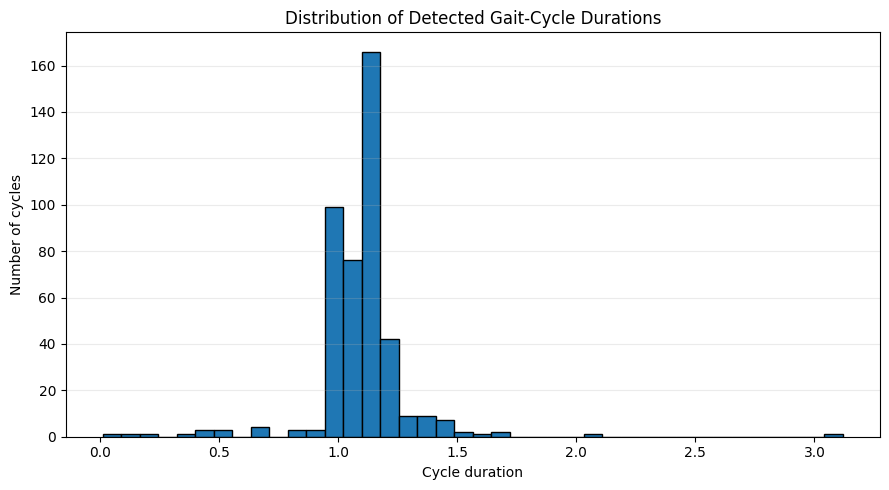

In [7]:
# CELL 5 — Plot cycle duration distribution

plt.figure(figsize=(9, 5))

plt.hist(
    cycle_quality["duration"],
    bins=40,
    edgecolor="black"
)

plt.xlabel("Cycle duration")
plt.ylabel("Number of cycles")
plt.title("Distribution of Detected Gait-Cycle Durations")

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()

In [8]:
# CELL 6 — Cycle duration by participant

duration_by_person = (
    cycle_quality
    .groupby("person")["duration"]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max"
    ])
)

display(
    duration_by_person.round(3)
)

,count,mean,median,std,min,max
person,,,,,,
Buddhini,77,1.041,1.100,0.252,0.16,1.44
Harshika,59,1.083,1.080,0.185,0.01,1.47
Muthuni,30,1.168,1.145,0.086,1.06,1.42
Nadeera,124,1.026,0.990,0.120,0.94,1.68
Thenuri,145,1.165,1.130,0.218,0.49,3.12


In [9]:
# CELL 7 — Inspect cycle lengths in sequence for every recording

for (person, trial, phase), group in (
    cycle_quality
    .groupby(["person", "trial", "phase"])
):

    group = group.sort_values("cycle_index")

    print(
        f"\n{person} | Trial {trial} | Phase {phase}"
    )

    print(
        group[
            ["cycle_index", "frames", "duration"]
        ].to_string(index=False)
    )


Buddhini | Trial 1 | Phase 02
 cycle_index  frames  duration
           1     130      1.29
           2     106      1.05
           3     110      1.09
           4     103      1.02
           5     109      1.08
           6     107      1.06
           7     110      1.09
           8     107      1.06
           9     110      1.09
          10     141      1.40

Buddhini | Trial 2 | Phase 02
 cycle_index  frames  duration
           1     138      1.37
           2     113      1.12
           3     107      1.06
           4     109      1.08
           5      66      0.65
           6      41      0.40
           7      65      0.64
           8      43      0.42
           9      68      0.67
          10      42      0.41
          11     110      1.09
          12      70      0.69
          13      40      0.39
          14     113      1.12
          15     123      1.22

Buddhini | Trial 3 | Phase 02
 cycle_index  frames  duration
           1     120      1.19
        

In [10]:
# CELL 8 — Flag cycles far from their recording's median duration

quality_check = cycle_quality.copy()

quality_check["recording_median_duration"] = (
    quality_check
    .groupby(["person", "trial", "phase"])["duration"]
    .transform("median")
)

quality_check["duration_ratio"] = (
    quality_check["duration"]
    / quality_check["recording_median_duration"]
)

# Diagnostic only — NOT yet an exclusion rule
quality_check["unusual"] = (
    (quality_check["duration_ratio"] < 0.70) |
    (quality_check["duration_ratio"] > 1.30)
)

unusual_cycles = (
    quality_check[
        quality_check["unusual"]
    ]
    .sort_values(
        ["person", "trial", "phase", "cycle_index"]
    )
)

print(
    "Cycles flagged for inspection:",
    len(unusual_cycles)
)

display(
    unusual_cycles[
        [
            "person",
            "trial",
            "phase",
            "cycle_index",
            "frames",
            "duration",
            "recording_median_duration",
            "duration_ratio"
        ]
    ].round(3)
)

Cycles flagged for inspection: 29


,person,trial,phase,cycle_index,frames,duration,recording_median_duration,duration_ratio
52,Buddhini,2,02,1,138,1.37,0.690,1.986
53,Buddhini,2,02,2,113,1.12,0.690,1.623
54,Buddhini,2,02,3,107,1.06,0.690,1.536
55,Buddhini,2,02,4,109,1.08,0.690,1.565
57,Buddhini,2,02,6,41,0.40,0.690,0.580
59,Buddhini,2,02,8,43,0.42,0.690,0.609
61,Buddhini,2,02,10,42,0.41,0.690,0.594
62,Buddhini,2,02,11,110,1.09,0.690,1.580
64,Buddhini,2,02,13,40,0.39,0.690,0.565
65,Buddhini,2,02,14,113,1.12,0.690,1.623


In [11]:
# CELL 9 — Inspect suspicious Buddhini Trial 2 segmentation

person = "Buddhini"
trial = "2"
phase = "02"

person_path = DATA_ROOT / person

candidate_files = []

for file in person_path.rglob("limb_angle_mode.csv"):

    relative = file.relative_to(person_path)
    parts = relative.parts

    file_trial = parts[0]

    phase_folder = parts[1] if len(parts) > 1 else ""

    if "Phase_" in phase_folder:
        file_phase = phase_folder.split("Phase_")[-1]
    else:
        file_phase = "UNKNOWN"

    if (
        str(file_trial) == trial
        and str(file_phase) == phase
    ):
        candidate_files.append(file)


print("Matching files:", len(candidate_files))

for file in candidate_files:
    print(file)

if len(candidate_files) != 1:
    raise ValueError(
        f"Expected exactly 1 matching file, found {len(candidate_files)}"
    )

target_file = candidate_files[0]

# Load recording
b2 = pd.read_csv(target_file)

# Keep valid periodic rows
b2_periodic = b2[
    (b2["segment_label"] == "periodic") &
    (b2["cycle_index"] >= 0)
].copy()

# Summarize every cycle
b2_cycle_summary = (
    b2_periodic
    .groupby("cycle_index")
    .agg(
        start_frame=("frame", "min"),
        end_frame=("frame", "max"),
        start_time=("time", "min"),
        end_time=("time", "max"),
        frames=("frame", "size")
    )
    .reset_index()
)

b2_cycle_summary["duration"] = (
    b2_cycle_summary["end_time"]
    - b2_cycle_summary["start_time"]
)

display(
    b2_cycle_summary.round(3)
)

Matching files: 1
C:\Users\MSI\OneDrive\Desktop\Gait and Posture\new G&P\data\Buddhini\2\combined_log_wide_1757660748_Phase_02\limb_angle_mode.csv


,cycle_index,start_frame,end_frame,start_time,end_time,frames,duration
0,1,279,416,2.79,4.16,138,1.37
1,2,417,529,4.17,5.29,113,1.12
2,3,530,636,5.30,6.36,107,1.06
3,4,637,745,6.37,7.45,109,1.08
4,5,746,811,7.46,8.11,66,0.65
5,6,812,852,8.12,8.52,41,0.40
6,7,853,917,8.53,9.17,65,0.64
7,8,918,960,9.18,9.60,43,0.42
8,9,961,1028,9.61,10.28,68,0.67
9,10,1029,1070,10.29,10.70,42,0.41


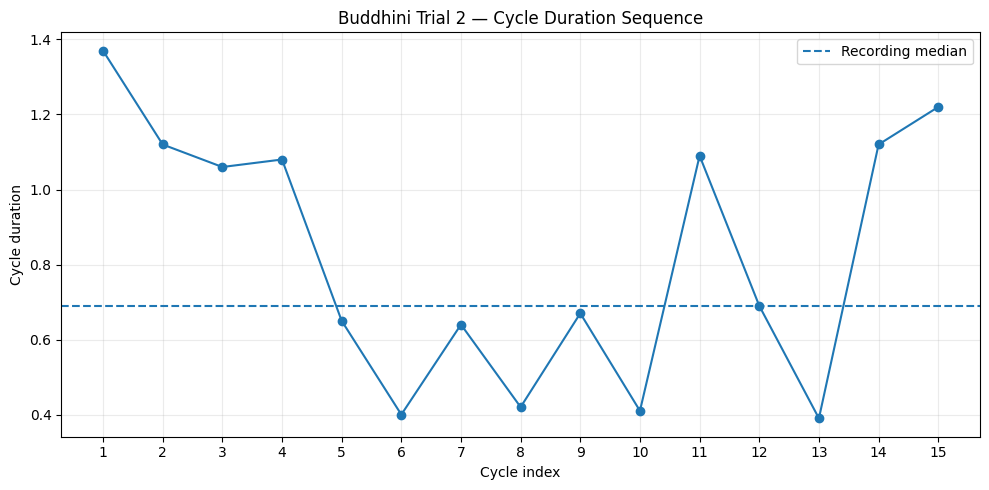

In [12]:
# CELL 10 — Buddhini Trial 2 cycle-duration sequence

plt.figure(figsize=(10, 5))

plt.plot(
    b2_cycle_summary["cycle_index"],
    b2_cycle_summary["duration"],
    marker="o"
)

plt.axhline(
    b2_cycle_summary["duration"].median(),
    linestyle="--",
    label="Recording median"
)

plt.xlabel("Cycle index")
plt.ylabel("Cycle duration")
plt.title("Buddhini Trial 2 — Cycle Duration Sequence")

plt.xticks(
    b2_cycle_summary["cycle_index"]
)

plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
# CELL 6 — Cycle duration by participant

duration_by_person = (
    cycle_quality
    .groupby("person")["duration"]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max"
    ])
)

display(
    duration_by_person.round(3)
)

,count,mean,median,std,min,max
person,,,,,,
Buddhini,77,1.041,1.100,0.252,0.16,1.44
Harshika,59,1.083,1.080,0.185,0.01,1.47
Muthuni,30,1.168,1.145,0.086,1.06,1.42
Nadeera,124,1.026,0.990,0.120,0.94,1.68
Thenuri,145,1.165,1.130,0.218,0.49,3.12


This is very revealing. Buddhini Trial 2 is not a case of just one incomplete first/last cycle. The suspicious durations occur in the middle of a continuous periodic segment.

Look at the sequence:
Cycle 1–4:    1.37, 1.12, 1.06, 1.08 s   ← normal-looking cluster

Cycle 5–10:   0.65, 0.40, 0.64,
              0.42, 0.67, 0.41 s          ← alternating short cycles

Cycle 11:     1.09 s

Cycle 12–13:  0.69, 0.39 s

Cycle 14–15:  1.12, 1.22 s

Even more importantly, the frame boundaries are perfectly continuous:
745 → 746, 811 → 812, 852 → 853, etc.

So there aren't missing chunks of data between these cycles. The cycle segmentation itself is changing behavior.
The pattern around cycles 5–10 is especially suspicious:
0.65 + 0.40 = 1.05 s
0.64 + 0.42 = 1.06 s
0.67 + 0.41 = 1.08 s

That's a huge clue.
Those pairs add up almost perfectly to the normal ~1.05–1.08 s cycle duration seen earlier in the recording.
So a very plausible explanation is that the segmentation algorithm has split some full gait cycles into two pieces.
For example:
Expected full cycle
|---------------------------|
          ~1.05 s

Detected:
|----------------|----------|
     0.65 s          0.40 s

And it happens repeatedly.
That means simply throwing out everything <0.8 s would be a bad solution. We'd be deleting pieces that potentially belong together.


Let's test whether the end of Cycle 5 flows naturally into the beginning of Cycle 6, Cycle 7 → 8, and Cycle 9 → 10.
next we  Plot suspicious consecutive cycles without normalization

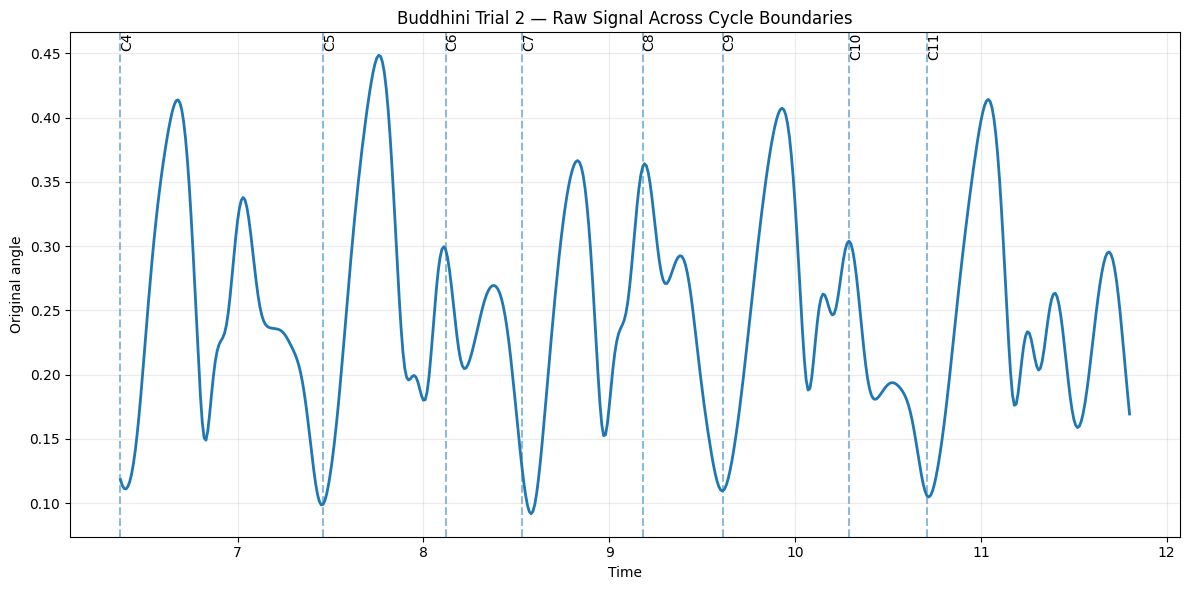

In [14]:
# CELL 11 — Inspect suspicious split-cycle pairs

SIGNAL = "right_hip_to_knee_original_angle"

plt.figure(figsize=(12, 6))

subset = b2_periodic[
    b2_periodic["cycle_index"].between(4, 11)
]

plt.plot(
    subset["time"],
    subset[SIGNAL],
    linewidth=2
)

# Draw cycle boundaries
for cycle_id, group in subset.groupby("cycle_index"):

    start_time = group["time"].iloc[0]

    plt.axvline(
        start_time,
        linestyle="--",
        alpha=0.5
    )

    plt.text(
        start_time,
        plt.ylim()[1],
        f"C{int(cycle_id)}",
        rotation=90,
        verticalalignment="top"
    )

plt.xlabel("Time")
plt.ylabel("Original angle")

plt.title(
    "Buddhini Trial 2 — Raw Signal Across Cycle Boundaries"
)

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [15]:
# CELL 12 — Signal discontinuity at detected cycle boundaries

boundary_records = []

cycle_ids = sorted(
    b2_periodic["cycle_index"].unique()
)

for previous_id, next_id in zip(
    cycle_ids[:-1],
    cycle_ids[1:]
):

    previous = b2_periodic[
        b2_periodic["cycle_index"] == previous_id
    ]

    next_cycle = b2_periodic[
        b2_periodic["cycle_index"] == next_id
    ]

    differences = []

    for signal in ORIGINAL_ANGLE_COLS:

        end_value = previous[signal].iloc[-1]
        start_value = next_cycle[signal].iloc[0]

        differences.append(
            abs(start_value - end_value)
        )

    boundary_records.append({
        "boundary": f"{int(previous_id)} → {int(next_id)}",
        "previous_duration":
            previous["time"].iloc[-1]
            - previous["time"].iloc[0],
        "next_duration":
            next_cycle["time"].iloc[-1]
            - next_cycle["time"].iloc[0],
        "mean_signal_jump": np.mean(differences),
        "max_signal_jump": np.max(differences)
    })

boundary_df = pd.DataFrame(boundary_records)

display(
    boundary_df.round(4)
)

,boundary,previous_duration,next_duration,mean_signal_jump,max_signal_jump
0,1 → 2,1.37,1.12,0.0145,0.0555
1,2 → 3,1.12,1.06,0.0107,0.0399
2,3 → 4,1.06,1.08,0.0129,0.0505
3,4 → 5,1.08,0.65,0.0107,0.0361
4,5 → 6,0.65,0.40,0.0092,0.0367
5,6 → 7,0.40,0.64,0.0123,0.0425
6,7 → 8,0.64,0.42,0.0083,0.0335
7,8 → 9,0.42,0.67,0.0090,0.0469
8,9 → 10,0.67,0.41,0.0091,0.0338
9,10 → 11,0.41,1.09,0.0110,0.0495


The raw signal is continuous across every cycle_index boundary. The mean jump across all 18 signals is only about 0.008–0.015, including the suspicious boundaries. There is no obvious discontinuity at 5→6, 7→8, or 9→10.
However, smooth continuity does not by itself prove that two neighboring labels should be merged. A correctly detected gait-cycle boundary should normally also occur along a continuous signal. What makes Buddhini Trial 2 suspicious is the combination of the smooth signal and the very structured duration pattern:

Cycles 1–4:       1.37, 1.12, 1.06, 1.08

Cycles 5–6:       0.65 + 0.40 = 1.05
Cycles 7–8:       0.64 + 0.42 = 1.06
Cycles 9–10:      0.67 + 0.41 = 1.08

Cycle 11:         1.09

Cycles 12–13:     0.69 + 0.39 = 1.08

Cycles 14–15:     1.12, 1.22

That is remarkably systematic. My current hypothesis is that cycle_index may sometimes be detecting subcycles/events rather than consistently defining one full gait cycle, or that the cycle-generation algorithm changed which event it used as a boundary. But we should not automatically merge them based only on duration.
The plot gives us a way to test that hypothesis more directly: check whether the short pairs, when joined, resemble the normal ~1.1 s cycles.
Next test: merge only the suspected pairs experimentally

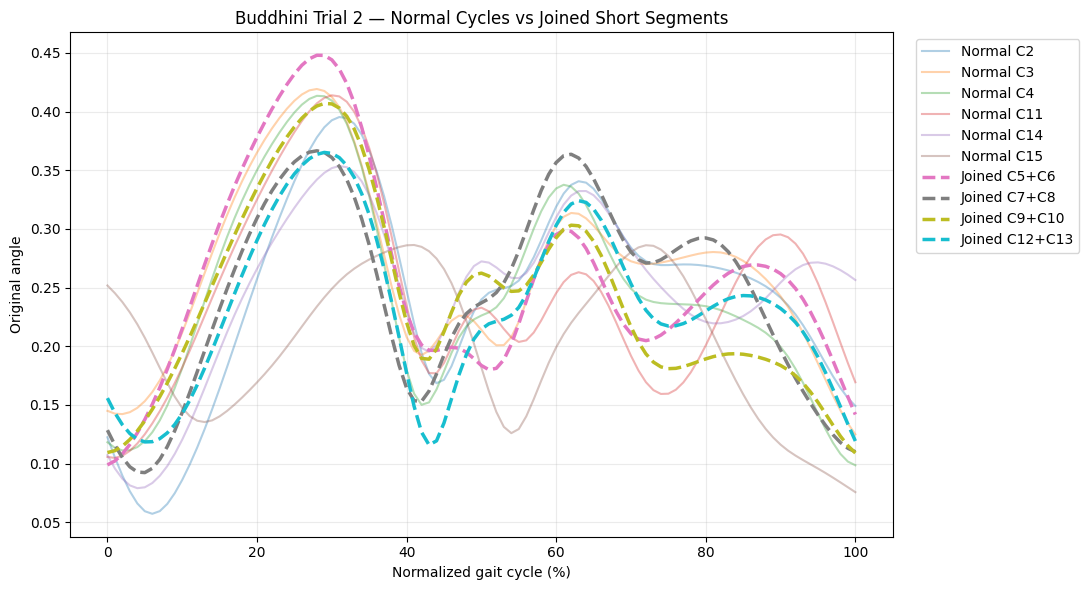

In [16]:
# CELL 13 — Compare normal cycles with experimentally joined short pairs

SIGNAL = "right_hip_to_knee_original_angle"

normal_ids = [2, 3, 4, 11, 14, 15]

suspected_pairs = [
    (5, 6),
    (7, 8),
    (9, 10),
    (12, 13)
]

TARGET_POINTS = 101
target_percent = np.linspace(0, 100, TARGET_POINTS)


def normalize_values(values):
    values = np.asarray(values)

    old_x = np.linspace(
        0,
        100,
        len(values)
    )

    return np.interp(
        target_percent,
        old_x,
        values
    )


plt.figure(figsize=(11, 6))


# --------------------------------
# Normal individual cycles
# --------------------------------

for cycle_id in normal_ids:

    cycle_data = (
        b2_periodic[
            b2_periodic["cycle_index"] == cycle_id
        ]
        .sort_values("time")
    )

    values = cycle_data[SIGNAL].to_numpy()

    normalized = normalize_values(values)

    plt.plot(
        target_percent,
        normalized,
        alpha=0.35,
        linewidth=1.5,
        label=f"Normal C{cycle_id}"
    )


# --------------------------------
# Experimentally joined pairs
# --------------------------------

for first, second in suspected_pairs:

    joined_data = (
        b2_periodic[
            b2_periodic["cycle_index"].isin(
                [first, second]
            )
        ]
        .sort_values("time")
    )

    values = joined_data[SIGNAL].to_numpy()

    normalized = normalize_values(values)

    plt.plot(
        target_percent,
        normalized,
        linewidth=2.5,
        linestyle="--",
        label=f"Joined C{first}+C{second}"
    )


plt.xlabel("Normalized gait cycle (%)")
plt.ylabel("Original angle")

plt.title(
    "Buddhini Trial 2 — Normal Cycles vs Joined Short Segments"
)

plt.grid(alpha=0.25)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [17]:
# CELL 14 — Compare experimentally joined pairs against normal cycles
# Self-contained version

SIGNAL = "right_hip_to_knee_original_angle"

normal_ids = [2, 3, 4, 11, 14, 15]

suspected_pairs = [
    (5, 6),
    (7, 8),
    (9, 10),
    (12, 13)
]

TARGET_POINTS = 101
target_percent = np.linspace(0, 100, TARGET_POINTS)


def normalize_values(values):
    values = np.asarray(values)

    old_x = np.linspace(
        0,
        100,
        len(values)
    )

    return np.interp(
        target_percent,
        old_x,
        values
    )


# -----------------------------
# Normal cycles
# -----------------------------

normal_waveforms = {}

for cycle_id in normal_ids:

    values = (
        b2_periodic.loc[
            b2_periodic["cycle_index"] == cycle_id,
            SIGNAL
        ]
        .to_numpy()
    )

    normal_waveforms[cycle_id] = (
        normalize_values(values)
    )


# -----------------------------
# Joined suspicious pairs
# -----------------------------

joined_waveforms = {}

for first, second in suspected_pairs:

    joined_data = (
        b2_periodic[
            b2_periodic["cycle_index"].isin(
                [first, second]
            )
        ]
        .sort_values("time")
    )

    values = joined_data[
        SIGNAL
    ].to_numpy()

    joined_waveforms[
        f"{first}+{second}"
    ] = normalize_values(values)


# -----------------------------
# Correlations
# -----------------------------

comparison_rows = []

for pair_name, joined in joined_waveforms.items():

    correlations = []

    for cycle_id, normal in normal_waveforms.items():

        r = np.corrcoef(
            joined,
            normal
        )[0, 1]

        correlations.append(r)

    comparison_rows.append({
        "joined_pair": pair_name,

        "mean_correlation_to_normal_cycles":
            np.mean(correlations),

        "median_correlation_to_normal_cycles":
            np.median(correlations),

        "max_correlation_to_normal_cycle":
            np.max(correlations),

        "min_correlation_to_normal_cycle":
            np.min(correlations)
    })


joined_comparison = pd.DataFrame(
    comparison_rows
)

display(
    joined_comparison.round(3)
)

,joined_pair,mean_correlation_to_normal_cycles,median_correlation_to_normal_cycles,max_correlation_to_normal_cycle,min_correlation_to_normal_cycle
0,5+6,0.712,0.816,0.947,0.100
1,7+8,0.728,0.822,0.924,0.301
2,9+10,0.733,0.798,0.949,0.259
3,12+13,0.770,0.870,0.937,0.210


All four joined pairs show fairly strong similarity to the normal-looking full cycles. Their median correlations are 0.798–0.870, and each has at least one normal cycle with correlation above 0.92. Combined with their durations:
C5 + C6   = 0.65 + 0.40 ≈ 1.05 s
C7 + C8   = 0.64 + 0.42 ≈ 1.06 s
C9 + C10  = 0.67 + 0.41 ≈ 1.08 s
C12 + C13 = 0.69 + 0.39 ≈ 1.08 s

that gives substantial evidence that these labels are likely split segments of complete cycles in Buddhini Trial 2.
The strongest is C12+C13: median correlation 0.870. But all four tell essentially the same story.
What we can conclude — and what we can't
We can reasonably write in our analysis notes:
In Buddhini Trial 2, several unusually short consecutive cycle segments occurred in complementary pairs whose combined durations were approximately 1.05–1.08 s. After concatenation and normalization, these paired segments showed substantial waveform similarity to normally segmented cycles (median Pearson correlations 0.798–0.870), suggesting possible over-segmentation of complete gait cycles.

But we cannot yet conclude that every short cycle in the entire dataset should be paired with its neighbor. That's where we'd risk creating artificial cycles.

In [18]:
# CELL 15 — Dataset-wide cycle quality table
# Diagnostic only: nothing is removed or relabeled.

quality_df = features_df[
    [
        "person",
        "trial",
        "phase",
        "cycle_index",
        "frames",
        "duration"
    ]
].copy()

print("Total cycles:", len(quality_df))

display(
    quality_df[
        ["frames", "duration"]
    ].describe()
)

print("\nCycle counts by person:")

display(
    quality_df
    .groupby("person")
    .size()
    .rename("cycles")
    .to_frame()
)

Total cycles: 435


,frames,duration
count,435.000000,435.000000
mean,110.234483,1.092345
std,19.992284,0.199923
min,2.000000,0.010000
25%,102.000000,1.010000
50%,111.000000,1.100000
75%,116.000000,1.150000
max,313.000000,3.120000



Cycle counts by person:


,cycles
person,
Buddhini,77
Harshika,59
Muthuni,30
Nadeera,124
Thenuri,145


In [19]:
# CELL 17 — Robust global cycle-length statistics

frame_median = quality_df["frames"].median()

frame_mad = np.median(
    np.abs(
        quality_df["frames"] - frame_median
    )
)

duration_median = quality_df["duration"].median()

duration_mad = np.median(
    np.abs(
        quality_df["duration"] - duration_median
    )
)

print(f"Frame median:    {frame_median:.2f}")
print(f"Frame MAD:       {frame_mad:.2f}")

print()

print(f"Duration median: {duration_median:.3f} s")
print(f"Duration MAD:    {duration_mad:.3f} s")

Frame median:    111.00
Frame MAD:       6.00

Duration median: 1.100 s
Duration MAD:    0.060 s


In [20]:
# CELL 18 — Inspect global extremes

cols = [
    "person",
    "trial",
    "phase",
    "cycle_index",
    "frames",
    "duration"
]

print("20 shortest cycles")
display(
    quality_df
    .sort_values("frames")
    [cols]
    .head(20)
)

print("\n20 longest cycles")
display(
    quality_df
    .sort_values("frames", ascending=False)
    [cols]
    .head(20)
)

20 shortest cycles


,person,trial,phase,cycle_index,frames,duration
115,Harshika,2,01,11,2,0.01
0,Buddhini,9,02,1,17,0.16
2,Buddhini,9,02,3,19,0.18
64,Buddhini,2,02,13,40,0.39
57,Buddhini,2,02,6,41,0.40
61,Buddhini,2,02,10,42,0.41
59,Buddhini,2,02,8,43,0.42
114,Harshika,2,01,10,49,0.48
355,Thenuri,3,01,24,50,0.49
331,Thenuri,4,02,21,51,0.50



20 longest cycles


,person,trial,phase,cycle_index,frames,duration
334,Thenuri,3,01,3,313,3.12
395,Thenuri,2,01,20,211,2.10
376,Thenuri,2,01,1,172,1.71
186,Nadeera,4,02,1,169,1.68
206,Nadeera,4,02,21,164,1.63
166,Nadeera,4,01,1,155,1.54
335,Thenuri,3,01,4,151,1.50
135,Harshika,1,02,10,148,1.47
354,Thenuri,3,01,23,146,1.45
249,Nadeera,2,02,1,145,1.44


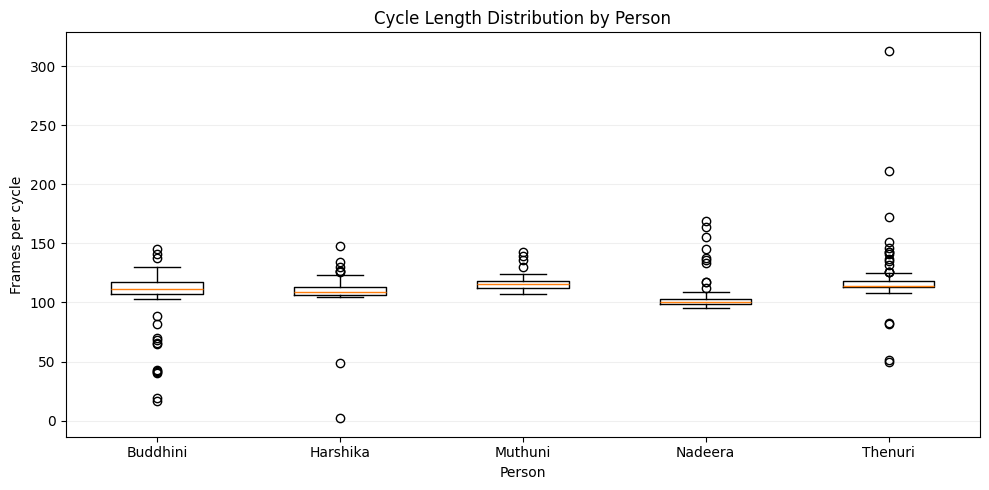

In [21]:
# CELL 19 — Person-level distributions

plt.figure(figsize=(10, 5))

people = sorted(quality_df["person"].unique())

data = [
    quality_df.loc[
        quality_df["person"] == person,
        "frames"
    ].values
    for person in people
]

plt.boxplot(
    data,
    tick_labels=people,
    showfliers=True
)

plt.ylabel("Frames per cycle")
plt.xlabel("Person")
plt.title("Cycle Length Distribution by Person")
plt.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

In [22]:
# CELL 20 — Conservative cycle-quality flags
# IMPORTANT: this does NOT modify the original cycle_index.

SHORT_FRAME_LIMIT = 80
LONG_FRAME_LIMIT = 180

def classify_cycle_quality(frames):
    if frames < SHORT_FRAME_LIMIT:
        return "suspicious_short"
    elif frames > LONG_FRAME_LIMIT:
        return "suspicious_long"
    else:
        return "plausible"

quality_df["cycle_quality"] = (
    quality_df["frames"]
    .apply(classify_cycle_quality)
)

display(
    quality_df["cycle_quality"]
    .value_counts()
    .to_frame("cycles")
)

,cycles
cycle_quality,
plausible,419
suspicious_short,14
suspicious_long,2


In [23]:
# CELL 21 — Inspect every conservatively flagged cycle

flagged_cycles = (
    quality_df[
        quality_df["cycle_quality"] != "plausible"
    ]
    .sort_values(["person", "trial", "phase", "cycle_index"])
)

print("Flagged cycles:", len(flagged_cycles))
print(
    f"Percentage flagged: "
    f"{100 * len(flagged_cycles) / len(quality_df):.2f}%"
)

display(
    flagged_cycles[
        [
            "person",
            "trial",
            "phase",
            "cycle_index",
            "frames",
            "duration",
            "cycle_quality"
        ]
    ]
)

Flagged cycles: 16
Percentage flagged: 3.68%


,person,trial,phase,cycle_index,frames,duration,cycle_quality
56,Buddhini,2,02,5,66,0.65,suspicious_short
57,Buddhini,2,02,6,41,0.40,suspicious_short
58,Buddhini,2,02,7,65,0.64,suspicious_short
59,Buddhini,2,02,8,43,0.42,suspicious_short
60,Buddhini,2,02,9,68,0.67,suspicious_short
61,Buddhini,2,02,10,42,0.41,suspicious_short
63,Buddhini,2,02,12,70,0.69,suspicious_short
64,Buddhini,2,02,13,40,0.39,suspicious_short
0,Buddhini,9,02,1,17,0.16,suspicious_short
2,Buddhini,9,02,3,19,0.18,suspicious_short


In [24]:
# CELL 22 — Quality counts by person

quality_by_person = pd.crosstab(
    quality_df["person"],
    quality_df["cycle_quality"]
)

quality_by_person["total"] = quality_by_person.sum(axis=1)

quality_by_person["flagged"] = (
    quality_by_person.get("suspicious_short", 0)
    + quality_by_person.get("suspicious_long", 0)
)

quality_by_person["flagged_pct"] = (
    100
    * quality_by_person["flagged"]
    / quality_by_person["total"]
)

display(quality_by_person)

cycle_quality,plausible,suspicious_long,suspicious_short,total,flagged,flagged_pct
person,,,,,,
Buddhini,67,0,10,77,10,12.987013
Harshika,57,0,2,59,2,3.389831
Muthuni,30,0,0,30,0,0.000000
Nadeera,124,0,0,124,0,0.000000
Thenuri,141,2,2,145,4,2.758621


In [25]:
# CELL 23 — Quality counts by independent recording

trial_quality = (
    quality_df
    .groupby(["person", "trial"])
    .agg(
        total_cycles=("cycle_index", "size"),
        plausible_cycles=(
            "cycle_quality",
            lambda x: (x == "plausible").sum()
        ),
        suspicious_short=(
            "cycle_quality",
            lambda x: (x == "suspicious_short").sum()
        ),
        suspicious_long=(
            "cycle_quality",
            lambda x: (x == "suspicious_long").sum()
        )
    )
    .reset_index()
)

trial_quality["plausible_pct"] = (
    100
    * trial_quality["plausible_cycles"]
    / trial_quality["total_cycles"]
)

display(
    trial_quality.sort_values(
        ["person", "trial"]
    )
)

,person,trial,total_cycles,plausible_cycles,suspicious_short,suspicious_long,plausible_pct
0,Buddhini,1,10,10,0,0,100.000000
1,Buddhini,2,15,7,8,0,46.666667
2,Buddhini,3,9,9,0,0,100.000000
3,Buddhini,4,9,9,0,0,100.000000
4,Buddhini,7,16,16,0,0,100.000000
5,Buddhini,9,18,16,2,0,88.888889
6,Harshika,1,10,10,0,0,100.000000
7,Harshika,2,21,19,2,0,90.476190
8,Harshika,3,9,9,0,0,100.000000
9,Harshika,4,10,10,0,0,100.000000


In [26]:
# CELL 24 — Attach quality labels to feature dataset

features_with_quality = features_df.merge(
    quality_df[
        [
            "person",
            "trial",
            "phase",
            "cycle_index",
            "cycle_quality"
        ]
    ],
    on=["person", "trial", "phase", "cycle_index"],
    how="left",
    validate="one_to_one"
)

assert len(features_with_quality) == len(features_df)
assert features_with_quality["cycle_quality"].notna().all()

print("Rows:", len(features_with_quality))
print("\nQuality counts:")
print(features_with_quality["cycle_quality"].value_counts())

print("\nMerge successful.")

Rows: 435

Quality counts:
cycle_quality
plausible           419
suspicious_short     14
suspicious_long       2
Name: count, dtype: int64

Merge successful.


In [27]:
# CELL 25 — Create full and conservative datasets

features_all = features_with_quality.copy()

features_clean = (
    features_with_quality[
        features_with_quality["cycle_quality"] == "plausible"
    ]
    .copy()
)

print("Experiment A — all supplied cycles:")
print(features_all.shape)

print("\nExperiment B — conservatively filtered cycles:")
print(features_clean.shape)

print(
    f"\nRemoved from sensitivity dataset: "
    f"{len(features_all) - len(features_clean)} cycles "
    f"({100 * (len(features_all) - len(features_clean)) / len(features_all):.2f}%)"
)

Experiment A — all supplied cycles:
(435, 97)

Experiment B — conservatively filtered cycles:
(419, 97)

Removed from sensitivity dataset: 16 cycles (3.68%)


In [28]:
from pathlib import Path

# FINAL CELL — Save feature dataset for modelling

ROOT = PROJECT_ROOT
OUTPUT_DIR = RESULTS_DIR
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PATH = OUTPUT_DIR / "cycle_features_with_quality.csv"

features_with_quality.to_csv(
    OUTPUT_PATH,
    index=False
)

print("Saved:", OUTPUT_PATH)
print("Shape:", features_with_quality.shape)

Saved: C:\Users\MSI\OneDrive\Desktop\Gait and Posture\new G&P\results\cycle_features_with_quality.csv
Shape: (435, 97)
